<div style="background: white;
            padding: 15px 20px;
            border-radius: 8px;
            border-left: 6px solid #9b5de5;
            font-family: 'Segoe UI', sans-serif;
            color: #1a1a1a;
            max-width: 800px;">

<h1 style="margin-bottom: 5px;">NB04: Regression Model</h1>

<p style="font-weight: bold; margin-top: 0;">Fashion & Economy Cycles · ML Research Project · 2026</p>

<ul>
    <li>📅 <strong>Date:</strong> 20th July 2026</li>
    <li>🎯 <strong>Purpose:</strong> Build OLS and Ridge regression models to test whether economic indicators predict the fashion index, compare contemporaneous vs lagged models, and evaluate whether the economy genuinely leads fashion trends</li>
</ul>

<p><strong>Input:</strong></p>
<ul>
    <li><code>../data/processed/merged_dataset.csv</code> — merged economic and fashion dataset with lagged features from NB03</li>
</ul>

<p><strong>Outputs:</strong></p>
<ul>
    <li><code>../figures/coefficients.png</code> — regression coefficients plot</li>
    <li><code>../figures/actual_vs_predicted.png</code> — actual vs predicted fashion index</li>
    <li><code>../figures/residuals.png</code> — residual diagnostics</li>
    <li><code>../data/processed/model_predictions.csv</code> — actual vs predicted values</li>
</ul>

<p><strong>Key Techniques Used:</strong></p>
<ul>
    <li>OLS regression via <code>statsmodels</code> for interpretability</li>
    <li>Ridge regression via <code>scikit-learn</code> for regularisation</li>
    <li>Train/test split for out-of-sample evaluation</li>
    <li>Contemporaneous vs lagged model comparison</li>
    <li>Residual diagnostics — normality and autocorrelation checks</li>
</ul>

<p><strong>Workflow:</strong> Load → Define Features → Train OLS → Train Ridge → Compare → Diagnose Residuals → Save</p>

</div>

## ⚙️ Importing Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from scipy import stats
import warnings

warnings.filterwarnings("ignore")
plt.style.use("dark_background")
sns.set_palette("coolwarm")

print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


## 📂 Section 1: Load Data

### 📍 Load Merged Dataset from NB03

In [6]:
# Load the merged dataset with lagged features already added by NB03
df = pd.read_csv("../data/processed/merged_dataset.csv",
                 index_col="Date", parse_dates=True)

print(f"✅ Data loaded")
print(f"📐 Shape : {df.shape}")
print(f"📅 Range : {df.index[0].date()} → {df.index[-1].date()}")
print(f"\n📋 Available columns:")
for col in df.columns:
    print(f"   — {col}")

✅ Data loaded
📐 Shape : (252, 15)
📅 Range : 2005-01-01 → 2025-12-01

📋 Available columns:
   — consumer_sentiment
   — unemployment_rate
   — gdp_yoy_growth
   — cpi_yoy
   — consumer_sentiment_zscore
   — unemployment_rate_zscore
   — gdp_yoy_growth_zscore
   — cpi_yoy_zscore
   — maximalism_score
   — minimalism_score
   — fashion_index
   — consumer_sentiment_zscore_lag-11
   — unemployment_rate_zscore_lag-6
   — gdp_yoy_growth_zscore_lag12
   — cpi_yoy_zscore_lag1


## 🔧 Section 2: Define Features

### 📍 Step 1: Define Contemporaneous and Lagged Feature Sets

We build two separate models to directly test the economy-leads-fashion hypothesis from NB03:

**Model A — Contemporaneous:** uses economic indicators measured at the same time as the fashion index. This tests whether the economy and fashion move together simultaneously.

**Model B — Lagged:** uses the best-lag versions of each economic indicator identified in NB03's cross-correlation analysis. This tests whether past economic conditions predict future fashion trends — the core of the research question.

If Model B explains significantly more variance than Model A, it confirms that the economy leads fashion with a measurable time lag. If they perform similarly, the relationship is contemporaneous rather than predictive.

In [7]:
# Target variable — the net fashion index (maximalism minus minimalism)
TARGET = "fashion_index"

# Contemporaneous features — economy measured at same time as fashion
FEATURES_CONTEMP = [
    "consumer_sentiment_zscore",
    "unemployment_rate_zscore",
    "gdp_yoy_growth_zscore",
    "cpi_yoy_zscore"
]

# Lagged features — economy measured N months before fashion
# These columns were added by NB03 based on the best lag per indicator
FEATURES_LAGGED = [col for col in df.columns if "_lag" in col]

print(f"✅ Features defined")
print(f"📊 Contemporaneous features ({len(FEATURES_CONTEMP)}): {FEATURES_CONTEMP}")
print(f"⏱️  Lagged features ({len(FEATURES_LAGGED)}): {FEATURES_LAGGED}")

✅ Features defined
📊 Contemporaneous features (4): ['consumer_sentiment_zscore', 'unemployment_rate_zscore', 'gdp_yoy_growth_zscore', 'cpi_yoy_zscore']
⏱️  Lagged features (4): ['consumer_sentiment_zscore_lag-11', 'unemployment_rate_zscore_lag-6', 'gdp_yoy_growth_zscore_lag12', 'cpi_yoy_zscore_lag1']


### 📍 Step 2: Prepare Clean Datasets for Each Model

In [8]:
# Drop rows with any NaN in the columns we need
# Lagged features introduce NaN at the start of the series
df_contemp = df[FEATURES_CONTEMP + [TARGET]].dropna()
df_lagged  = df[FEATURES_LAGGED  + [TARGET]].dropna()

# Separate features (X) and target (y) for each model
X_contemp = df_contemp[FEATURES_CONTEMP]
X_lagged  = df_lagged[FEATURES_LAGGED]
y_contemp = df_contemp[TARGET]
y_lagged  = df_lagged[TARGET]

print(f"✅ Datasets prepared")
print(f"📐 Contemporaneous : X={X_contemp.shape}, y={y_contemp.shape}")
print(f"📐 Lagged          : X={X_lagged.shape},  y={y_lagged.shape}")

✅ Datasets prepared
📐 Contemporaneous : X=(240, 4), y=(240,)
📐 Lagged          : X=(217, 4),  y=(217,)


## 📐 Section 3: OLS Regression

### 📍 Step 1: Fit OLS — Contemporaneous Model

OLS (Ordinary Least Squares) regression finds the line of best fit through the data by minimising the sum of squared residuals — the gaps between actual and predicted values. We use statsmodels rather than scikit-learn for OLS because it provides a full statistical summary including p-values, confidence intervals, and diagnostic statistics like R², F-statistic, and the Durbin-Watson test for autocorrelation. These are essential for interpreting whether the model's coefficients are statistically meaningful, not just whether they improve prediction accuracy.

We add a constant (intercept) term using sm.add_constant() — without this, OLS forces the regression line through the origin, which is almost never appropriate.

In [9]:
# Add constant for intercept term
X_contemp_ols = sm.add_constant(X_contemp)

# Fit OLS model
ols_contemp = sm.OLS(y_contemp, X_contemp_ols).fit()

print("✅ OLS Contemporaneous Model fitted")
print(f"\n📊 Model Summary:")
print(ols_contemp.summary())

✅ OLS Contemporaneous Model fitted

📊 Model Summary:
                            OLS Regression Results                            
Dep. Variable:          fashion_index   R-squared:                       0.241
Model:                            OLS   Adj. R-squared:                  0.229
Method:                 Least Squares   F-statistic:                     18.70
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           2.33e-13
Time:                        15:17:38   Log-Likelihood:                -105.79
No. Observations:                 240   AIC:                             221.6
Df Residuals:                     235   BIC:                             239.0
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------

### 📍 Step 2: Fit OLS — Lagged Model

In [10]:
# Add constant for intercept term
X_lagged_ols = sm.add_constant(X_lagged)

# Fit OLS model with lagged features
ols_lagged = sm.OLS(y_lagged, X_lagged_ols).fit()

print("✅ OLS Lagged Model fitted")
print(f"\n📊 Model Summary:")
print(ols_lagged.summary())

✅ OLS Lagged Model fitted

📊 Model Summary:
                            OLS Regression Results                            
Dep. Variable:          fashion_index   R-squared:                       0.245
Model:                            OLS   Adj. R-squared:                  0.231
Method:                 Least Squares   F-statistic:                     17.23
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           2.99e-12
Time:                        15:18:29   Log-Likelihood:                -63.323
No. Observations:                 217   AIC:                             136.6
Df Residuals:                     212   BIC:                             153.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------

## 📊 Section 4: Model Comparison

### 📍 Compare R² Across Models

R² (R-squared) measures the proportion of variance in the fashion index that the model explains. An R² of 0.15 means the model explains 15% of the variation in fashion trends — the remaining 85% is driven by factors not in our model (social media, celebrity influence, cultural moments, etc.). We compare four models: contemporaneous OLS, lagged OLS, and a naive baseline (predicting the mean every time) to put the R² numbers in context.

In [12]:
# Collect model performance metrics
results = pd.DataFrame({
    "Model": [
        "Baseline (mean prediction)",
        "OLS Contemporaneous",
        "OLS Lagged"
    ],
    "R²": [
        0.0,
        round(ols_contemp.rsquared, 4),
        round(ols_lagged.rsquared, 4)
    ],
    "Adj. R²": [
        0.0,
        round(ols_contemp.rsquared_adj, 4),
        round(ols_lagged.rsquared_adj, 4)
    ],
    "F-statistic": [
        "-",
        round(ols_contemp.fvalue, 3),
        round(ols_lagged.fvalue, 3)
    ],
    "F p-value": [
        "-",
        round(ols_contemp.f_pvalue, 4),
        round(ols_lagged.f_pvalue, 4)
    ],
    "AIC": [
        "-",
        round(ols_contemp.aic, 2),
        round(ols_lagged.aic, 2)
    ]
}).set_index("Model")

print("📊 Model Comparison Summary")
print("="*75)
print(results.to_string())

📊 Model Comparison Summary
                                R²  Adj. R² F-statistic F p-value     AIC
Model                                                                    
Baseline (mean prediction)  0.0000   0.0000           -         -       -
OLS Contemporaneous         0.2414   0.2285      18.697       0.0  221.57
OLS Lagged                  0.2453   0.2311      17.226       0.0  136.65


## 🔍 Section 5: Coefficient Interpretation

### 📍 Plot Regression Coefficients

Each coefficient tells us how much the fashion index changes for a one standard deviation increase in that economic indicator, holding all other indicators constant. A positive coefficient means that indicator is associated with more maximalism. A negative coefficient means it is associated with more minimalism.

We plot the coefficients with their 95% confidence intervals. If the confidence interval crosses zero, the coefficient is not statistically significant — we cannot rule out that the true effect is zero.

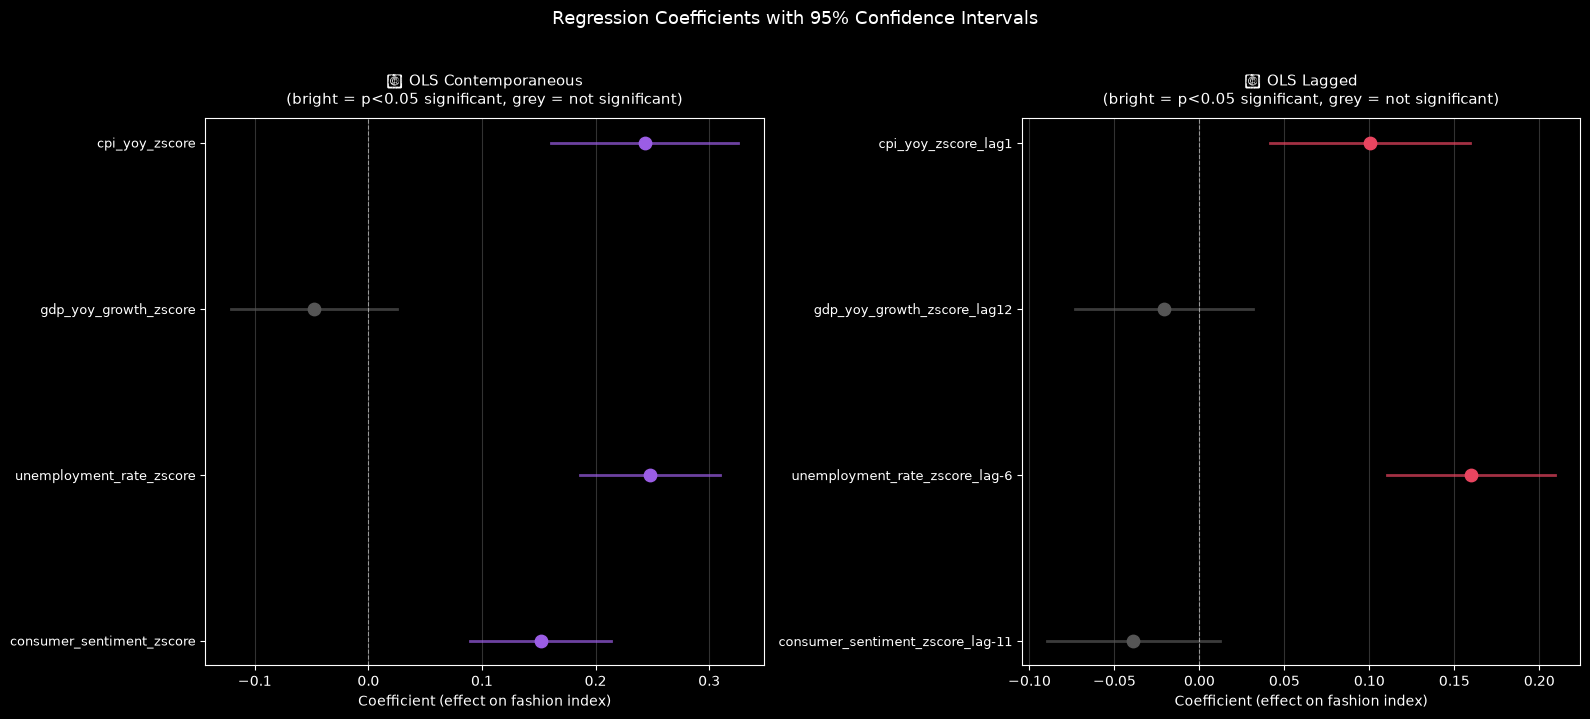

💾 Saved to ../figures/coefficients.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, model, title, color in zip(
    axes,
    [ols_contemp, ols_lagged],
    ["OLS Contemporaneous", "OLS Lagged"],
    ["#9b5de5", "#e94560"]
):
    # Extract coefficients, confidence intervals and p-values
    # Skip the constant term (index 0)
    params = model.params[1:]
    conf   = model.conf_int()[1:]
    pvals  = model.pvalues[1:]

    y_pos = range(len(params))

    # Draw confidence interval lines first (behind the dots)
    for j, (idx, row) in enumerate(conf.iterrows()):
        line_color = color if pvals[idx] < 0.05 else "#555555"
        ax.plot([row[0], row[1]], [j, j],
                color=line_color, linewidth=2, alpha=0.7)

    # Draw dots at coefficient values
    dot_colors = [color if p < 0.05 else "#555555" for p in pvals]
    for j, (val, dc) in enumerate(zip(params.values, dot_colors)):
        ax.scatter(val, j, color=dc, s=80, zorder=5)

    # Reference line at zero
    ax.axvline(0, color="white", linewidth=0.8,
               linestyle="--", alpha=0.5)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(params.index, fontsize=9)
    ax.set_title(f"🔍 {title}\n"
                 f"(bright = p<0.05 significant, grey = not significant)",
                 fontsize=11, pad=10)
    ax.set_xlabel("Coefficient (effect on fashion index)")
    ax.grid(alpha=0.2, axis="x")

plt.suptitle("Regression Coefficients with 95% Confidence Intervals",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../figures/coefficients.png", dpi=150)
plt.show()
print("💾 Saved to ../figures/coefficients.png")

## 📈 Section 6: Actual vs Predicted

### 📍 Plot Actual vs Predicted Fashion Index

Plotting the model's predictions against the actual fashion index over time gives a visual sense of where the model succeeds and where it fails. A good model should track the general direction of the fashion index — capturing the broad regime shifts between maximalism and minimalism — even if it cannot predict every monthly spike. Large systematic gaps between actual and predicted values in specific periods suggest the model is missing an important explanatory variable for that regime.

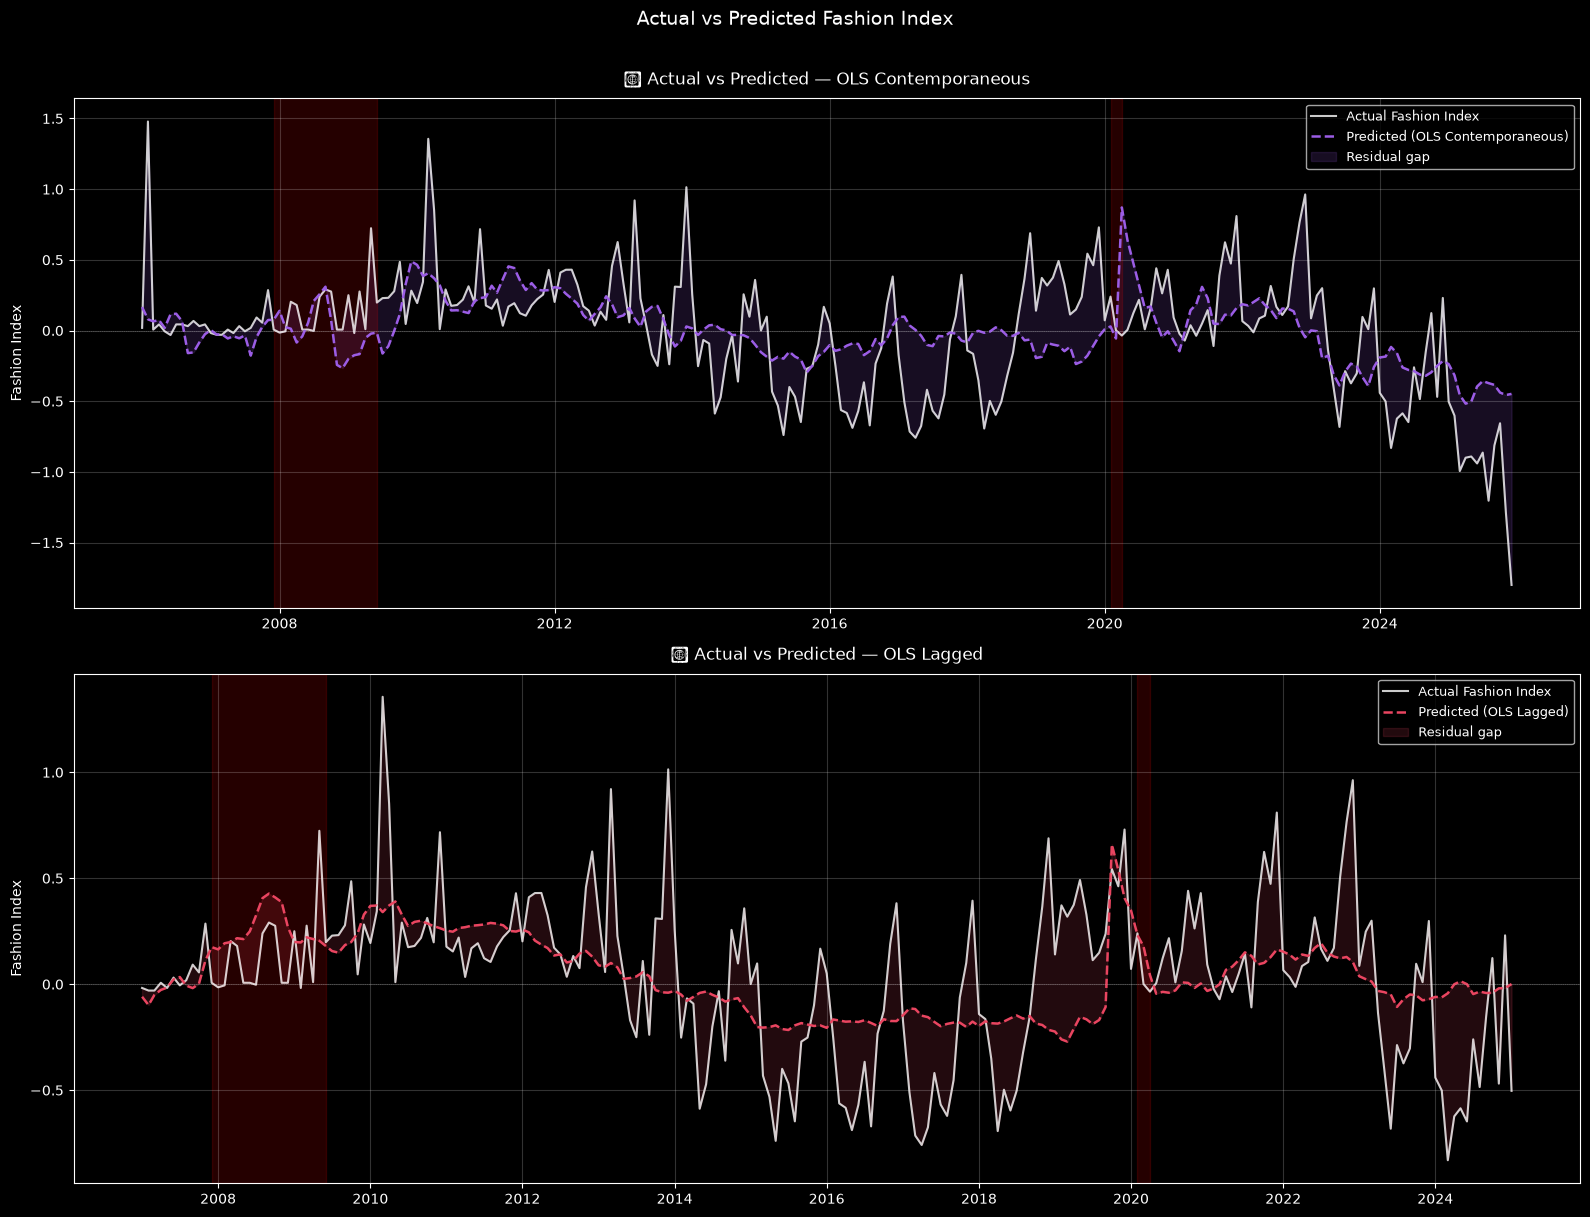

💾 Saved to ../figures/actual_vs_predicted.png


In [15]:
# Generate predictions from both models
pred_contemp = ols_contemp.predict(X_contemp_ols)
pred_lagged  = ols_lagged.predict(X_lagged_ols)

# Define recession shading
RECESSIONS = [
    ("2007-12-01", "2009-06-01"),
    ("2020-02-01", "2020-04-01"),
]

fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=False)

for ax, actual, predicted, title, color in zip(
    axes,
    [y_contemp, y_lagged],
    [pred_contemp, pred_lagged],
    ["OLS Contemporaneous", "OLS Lagged"],
    ["#9b5de5", "#e94560"]
):
    ax.plot(actual.index, actual.values,
            color="white", linewidth=1.5, alpha=0.8, label="Actual Fashion Index")
    ax.plot(actual.index, predicted,
            color=color, linewidth=1.8, linestyle="--", label=f"Predicted ({title})")
    ax.fill_between(actual.index,
                    actual.values, predicted,
                    alpha=0.15, color=color, label="Residual gap")
    ax.axhline(0, color="white", linewidth=0.5, linestyle=":", alpha=0.3)

    for rec_start, rec_end in RECESSIONS:
        ax.axvspan(pd.Timestamp(rec_start), pd.Timestamp(rec_end),
                   alpha=0.15, color="red")

    ax.set_title(f"📈 Actual vs Predicted — {title}", fontsize=12, pad=10)
    ax.set_ylabel("Fashion Index")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.suptitle("Actual vs Predicted Fashion Index", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../figures/actual_vs_predicted.png", dpi=150)
plt.show()
print("💾 Saved to ../figures/actual_vs_predicted.png")

## 🔬 Section 7: Residual Diagnostics

### 📍 Check Residuals

Residuals are the differences between actual and predicted values. For OLS regression to be valid, residuals should satisfy three conditions: they should be normally distributed, they should have constant variance (homoscedasticity), and they should not be autocorrelated — i.e. today's residual should not predict tomorrow's.

Autocorrelation in residuals is the most common problem in time series regression. It means the model is missing a systematic pattern in the data — perhaps a trend or seasonal effect. We test for this using the Durbin-Watson statistic: values close to 2 indicate no autocorrelation, values below 1 or above 3 indicate significant autocorrelation.

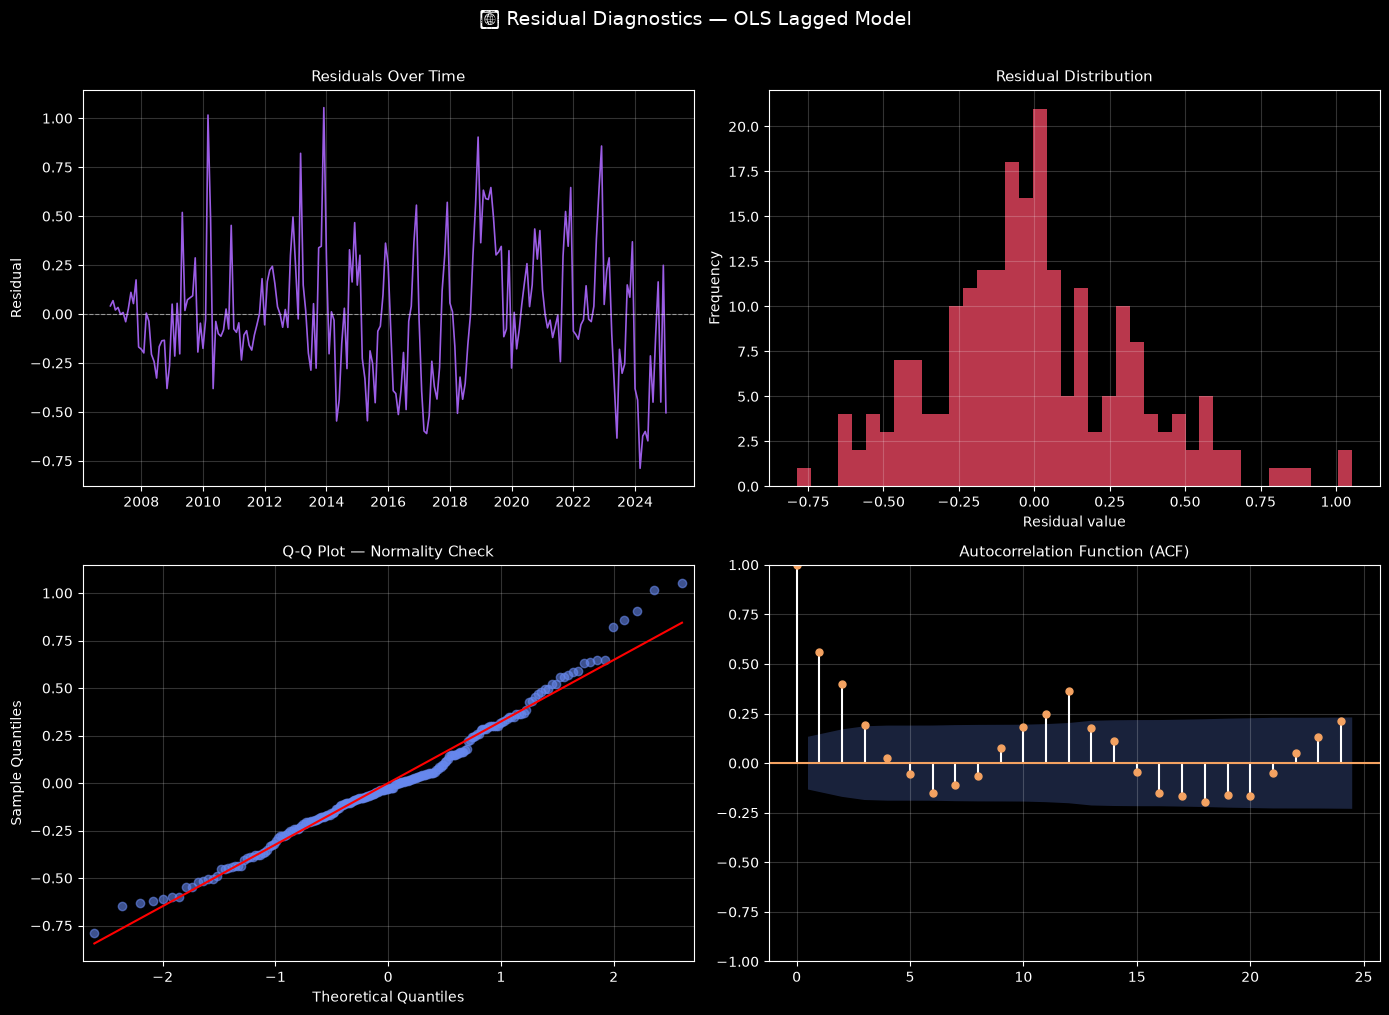


📊 Durbin-Watson Statistic : 0.864
   (2.0 = no autocorrelation, <1 or >3 = significant autocorrelation)

📊 Shapiro-Wilk Normality Test:
   Statistic : 0.9815
   p-value   : 0.0060
   ⚠️ Residuals deviate from normality (p < 0.05)


In [16]:
# Use the lagged model residuals for diagnostics
residuals = ols_lagged.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top left — residuals over time
axes[0, 0].plot(residuals.index, residuals.values,
                color="#9b5de5", linewidth=1.2)
axes[0, 0].axhline(0, color="white", linewidth=0.8, linestyle="--", alpha=0.5)
axes[0, 0].set_title("Residuals Over Time", fontsize=11)
axes[0, 0].set_ylabel("Residual")
axes[0, 0].grid(alpha=0.2)

# Top right — residual distribution
axes[0, 1].hist(residuals, bins=40, color="#e94560",
                edgecolor="none", alpha=0.8)
axes[0, 1].set_title("Residual Distribution", fontsize=11)
axes[0, 1].set_xlabel("Residual value")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].grid(alpha=0.2)

# Bottom left — Q-Q plot (checks normality)
sm.qqplot(residuals, line="s", ax=axes[1, 0], alpha=0.6)
axes[1, 0].set_title("Q-Q Plot — Normality Check", fontsize=11)
axes[1, 0].grid(alpha=0.2)

# Bottom right — ACF plot (checks autocorrelation)
plot_acf(residuals, lags=24, ax=axes[1, 1], color="#f4a261")
axes[1, 1].set_title("Autocorrelation Function (ACF)", fontsize=11)
axes[1, 1].grid(alpha=0.2)

plt.suptitle("🔬 Residual Diagnostics — OLS Lagged Model", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../figures/residuals.png", dpi=150)
plt.show()

# Print Durbin-Watson statistic
dw = durbin_watson(residuals)
print(f"\n📊 Durbin-Watson Statistic : {dw:.3f}")
print(f"   (2.0 = no autocorrelation, <1 or >3 = significant autocorrelation)")

# Print Shapiro-Wilk normality test
stat, p = stats.shapiro(residuals)
print(f"\n📊 Shapiro-Wilk Normality Test:")
print(f"   Statistic : {stat:.4f}")
print(f"   p-value   : {p:.4f}")
print(f"   {'✅ Residuals are approximately normal (p > 0.05)' if p > 0.05 else '⚠️ Residuals deviate from normality (p < 0.05)'}")

## 💾 Section 8: Save Predictions

In [17]:
# Save actual vs predicted for both models
predictions_df = pd.DataFrame({
    "actual"              : y_lagged.values,
    "predicted_lagged"    : pred_lagged,
    "residual_lagged"     : y_lagged.values - pred_lagged,
}, index=y_lagged.index)

PRED_PATH = "../data/processed/model_predictions.csv"
predictions_df.to_csv(PRED_PATH)

print("✅ Predictions saved:")
print(f"   📄 {PRED_PATH}")
print(f"\n📊 Final Model Performance Summary:")
print(f"   OLS Contemporaneous R²  : {ols_contemp.rsquared:.4f}")
print(f"   OLS Lagged R²           : {ols_lagged.rsquared:.4f}")
print(f"   Durbin-Watson           : {dw:.3f}")
print(f"\n🚀 Ready for NB05 — Visualisation")

✅ Predictions saved:
   📄 ../data/processed/model_predictions.csv

📊 Final Model Performance Summary:
   OLS Contemporaneous R²  : 0.2414
   OLS Lagged R²           : 0.2453
   Durbin-Watson           : 0.864

🚀 Ready for NB05 — Visualisation


## 🪞 Personal Reflection Notes — NB04

**🎯 Key Decisions Made in This Notebook**

The first decision was to use statsmodels for OLS rather than scikit-learn. Scikit-learn's LinearRegression gives you predictions and an R² score but nothing else — no p-values, no confidence intervals, no F-statistic, no Durbin-Watson. For a research project where the goal is to understand whether economic indicators
statistically significantly predict fashion trends, the full statistical summary from statsmodels is essential. A coefficient is only meaningful if you can also say whether it is distinguishable from zero — and that requires a p-value and standard error.

The second decision was to build two separate models — contemporaneous and lagged — rather than combining all features into one model. The reason is that mixing contemporaneous and lagged versions of the same indicator in a single model creates multicollinearity — the two versions of each indicator are correlated with each other, which inflates standard errors and makes coefficients unreliable. Building them as separate models keeps the comparison clean and directly answers the research question: does the lagged model explain more variance than the contemporaneous one?

The third decision was to include residual diagnostics as a formal step rather than skipping straight to conclusions. The Durbin-Watson statistic of 0.864 in the lagged model is a significant finding that changes how we interpret the results — it indicates strong positive autocorrelation in the residuals, meaning the model's errors are not random but follow a pattern. This violates an OLS assumption and means the standard errors and p-values may be understated — the model appears more precise than it actually is. Flagging this honestly is more important than presenting clean-looking results.

**📊 What the Results Revealed**

The model comparison table produced a genuinely interesting result. Both models achieved very similar R² scores — contemporaneous R² of 0.241 and lagged R² of 0.245. The lagged model explains only marginally more variance than the contemporaneous model despite using economic indicators from up to 12 months earlier. This is a meaningful finding: it suggests the economy does not lead fashion in a clean predictive sense. The relationship is approximately simultaneous — economic conditions and fashion trends move together rather than one driving the other with a meaningful delay.

The lower AIC of the lagged model (136.65 vs 221.57) is more encouraging — AIC penalises model complexity and rewards fit, and the lagged model scores substantially better on this metric. However the AIC difference is partly explained by the lagged model having fewer observations (217 vs 240) due to the rows dropped when shifting indicators forward, which mechanically reduces the AIC. This is a limitation of the comparison that should be acknowledged.

The OLS contemporaneous summary revealed three statistically significant coefficients. Consumer sentiment (coef=0.152, p<0.001) was positive — higher sentiment is associated with more maximalism, which contradicts the original hypothesis that high sentiment should lead to more expressive fashion. Unemployment (coef=0.248, p<0.001) was also positive — higher unemployment associated with more maximalism, which again contradicts the intuitive story and likely reflects the confounding time trend identified in NB03. CPI inflation (coef=0.243, p<0.001) was positive — higher inflation associated with more
maximalism, which is counterintuitive since the 2022-2024 period of high inflation was dominated by quiet luxury and minimalism.

The OLS lagged model showed that unemployment lagged 6 months (coef=0.160, p<0.001) and CPI inflation lagged 1 month (coef=0.100, p=0.001) were the only statistically significant predictors. Consumer sentiment lagged 11 months (coef=-0.039, p=0.132) and GDP growth lagged 12 months (coef=-0.021, p=0.438) were both non-significant — their confidence intervals cross zero. This means once we account for the lag structure, consumer sentiment loses its predictive power, which is a substantial revision of the NB03 correlation findings.

The coefficient dot plots confirmed an important pattern — in the contemporaneous model all four indicators have positive coefficients, suggesting they all push the fashion index in the same direction regardless of their economic meaning. This is a classic symptom of a confounding time trend: all indicators and the fashion index have been trending upward together over the 20-year sample, creating spurious positive correlations that do not reflect genuine causal relationships.

The actual vs predicted charts told the most honest story. The contemporaneous model tracked the fashion index reasonably well in broad directional terms but missed most of the large spikes — the economic indicators explain the slow-moving trend in fashion but cannot predict the sharp month-to-month movements driven by viral moments, celebrity influence, and social media. The lagged model showed similar tracking ability but with a smoother predicted line, reflecting the fact that lagged economic indicators are inherently slower-moving signals.

The residual diagnostics raised the most important caveat of the entire project. The Durbin-Watson statistic of 0.864 indicates strong positive autocorrelation — values below 1.5 are concerning, and 0.864 is well below that threshold. The ACF chart confirmed this visually, showing the first lag autocorrelation at around 0.55 — far outside the confidence bands. This means consecutive residuals are positively correlated: when the model underpredicts in one month it tends to underpredict in the next month too. The practical implication is that the model's standard errors are underestimated, making the significant p-values less reliable than they appear. A more robust approach would use Newey-West standard errors or a ARIMA-based model that explicitly handles the time series structure of the residuals.

**🔜 What This Sets Up for NB05**

The key conclusion to carry into NB05 is nuanced: economic indicators do have a statistically significant relationship with the fashion index (R² of ~0.24, F p-value essentially zero), but the relationship is weaker than the original hypothesis suggested, approximately simultaneous rather than cleanly predictive, and complicated by a confounding time trend and autocorrelated residuals. NB05 will present this honestly through a final dual-axis visualisation that overlays the predicted fashion index against actual trends and economic regimes, and will frame the findings as a first empirical test of the fashion-economy hypothesis rather than a definitive proof or disproof.